In [2]:
import os, time
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras_hub

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.regularizers import l2


In [3]:
print("TensorFlow:", tf.__version__)
physical_devices = tf.config.list_physical_devices('GPU')
print(physical_devices[0])
tf.config.experimental.set_memory_growth(physical_devices[0], True)

TensorFlow: 2.20.0
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_CLASSES = 45   # RESISC45 has 45 scene classes
EPOCHS      = 30
AUTOTUNE    = tf.data.AUTOTUNE


In [6]:
# RESISC45 – 45 scene classes, 700 images/class, 256×256 RGB
# Images are already 256×256 so no resize step needed in preprocessing

(train_raw, val_raw, test_raw), info_ds = tfds.load(
    'resisc45',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    shuffle_files=False,   # must be False with percentage splits
    as_supervised=True,
    with_info=True
)

CLASS_NAMES = info_ds.features['label'].names
total       = info_ds.splits['train'].num_examples

print(f'Classes          : {NUM_CLASSES}')
print(f'Class names      : {CLASS_NAMES}')
print(f'Train (~70%)     : ~{int(total * 0.70)}')
print(f'Val   (~15%)     : ~{int(total * 0.15)}')
print(f'Test  (~15%)     : ~{int(total * 0.15)}')
print(f'Images per class : ~{int(total * 0.70) // NUM_CLASSES} (train)')

for image, label in train_raw.take(3):
    print(f'Label: {label.numpy()} → {CLASS_NAMES[label.numpy()]}, Image shape: {image.shape}')


Classes selected: ['apple_pie', 'cup_cakes', 'french_fries', 'hamburger', 'ice_cream', 'macarons', 'pizza', 'ramen', 'sushi', 'waffles']

train data set: 6000 | validation data set: 2500

Label: 9 → waffles, Image shape: (512, 512, 3)
Label: 1 → cup_cakes, Image shape: (512, 512, 3)
Label: 2 → french_fries, Image shape: (512, 512, 3)
Label: 6 → pizza, Image shape: (512, 512, 3)
Label: 4 → ice_cream, Image shape: (512, 512, 3)


In [7]:
builder = tfds.builder('resisc45')
for split_name, split_info in builder.info.splits.items():
    print(f'{split_name}: {split_info.num_shards} shards, {split_info.num_examples} examples')


train: 32 shards, 75750 examples
validation: 16 shards, 25250 examples


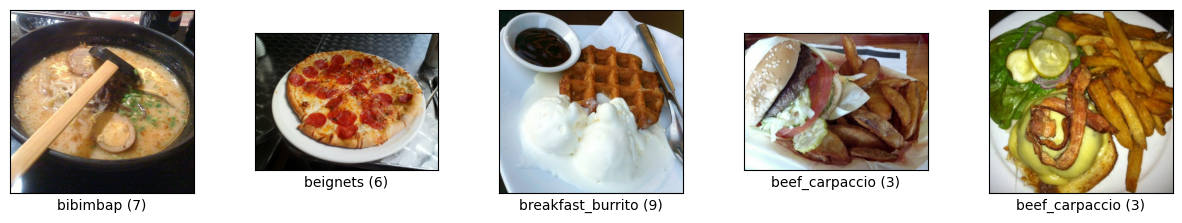

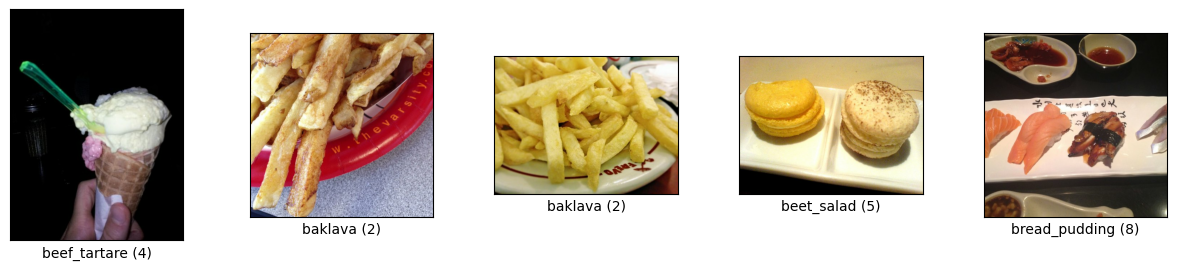

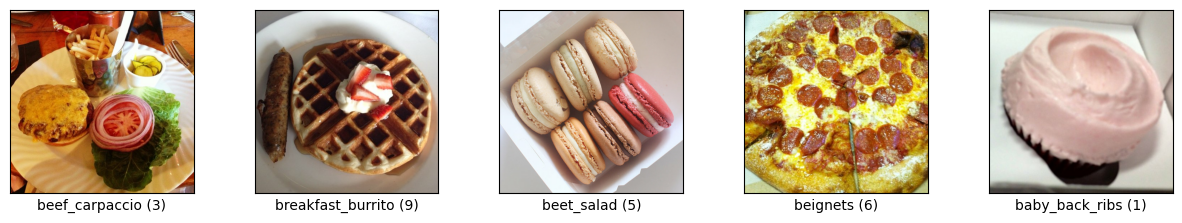

In [10]:
fig = tfds.show_examples(train_raw, info_ds, rows=1, cols=5)
fig = tfds.show_examples(val_raw,   info_ds, rows=1, cols=5)
fig = tfds.show_examples(test_raw,  info_ds, rows=1, cols=5)


In [11]:
# RESISC45 images are already 256×256 — no tf.image.resize needed

def preprocess_train_ds(image, label):
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])  # 256→224 random crop
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)   # valid: satellite has no fixed 'up'
    image = tf.image.random_brightness(image, 0.2)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def preprocess_ds(image, label):
    image = tf.image.central_crop(image, 0.875)        # 256 × 0.875 = 224 — deterministic
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label


train_ds = (
    train_raw
    .cache()
    .map(preprocess_train_ds, num_parallel_calls=AUTOTUNE)
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_raw
    .map(preprocess_ds, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess_ds, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [12]:
resnet50_base = tf.keras.applications.ResNet50(
                weights='imagenet',
                include_top=False,
                input_shape=(IMG_SIZE, IMG_SIZE, 3))
resnet50_base.trainable = False

print(f"{'Layer (type)':<25} | {'Output Shape':<20} | {'Params':<10}")
print("-" * 65)

# First 10 layers of ResNet_50
for layer in resnet50_base.layers[:10]:
    name = layer.name
    shape = str(layer.output.shape)
    params = f"{layer.count_params():,}"
    print(f"{name:<25} | {shape:<20} | {params:<10}")




94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Layer (type)              | Output Shape         | Params    
-----------------------------------------------------------------
input_layer               | (None, 224, 224, 3)  | 0         
conv1_pad                 | (None, 230, 230, 3)  | 0         
conv1_conv                | (None, 112, 112, 64) | 9,472     
conv1_bn                  | (None, 112, 112, 64) | 256       
conv1_relu                | (None, 112, 112, 64) | 0         
pool1_pad                 | (None, 114, 114, 64) | 0         
pool1_pool                | (None, 56, 56, 64)   | 0         
conv2_block1_1_conv       | (None, 56, 56, 64)   | 4,160     
conv2_block1_1_bn         | (None, 56, 56, 64)   | 256       
conv2_block1_1_relu       | (None, 56, 56, 64)   | 0         


In [13]:
# --- MODEL 1: ResNet_50 base ---

model_base = tf.keras.Sequential()
model_base.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model_base.add(resnet50_base)                                # spectial_features
model_base.add(tf.keras.layers.GlobalAveragePooling2D())                      # pooled_features
model_base.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

# img_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# spatial_features = resnet50_model(img_input, training= False)
# pooled_features = tf.keras.layers.GlobalAveragePooling2D()(spatial_features)
# class_probabilities = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(pooled_features)
# flower_model_simple = tf.keras.Model(img_input, class_probabilities)

model_base.compile(
        optimizer= 'adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
)

model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
print('BATCH_SIZE:', BATCH_SIZE)
print('NUM_CLASSES:', NUM_CLASSES)

# Check one batch shape
for x, y in train_ds.take(1):
    print('Batch shape:', x.shape)
    print('Sample labels:', y.numpy()[:10])
    print('Sample class names:', [CLASS_NAMES[l] for l in y.numpy()[:5]])


BATCH_SIZE: 64
Training examples after filter: 6013
Batch shape: (64, 224, 224, 3)
Labels: [8 6 5 2 4 4 6 3 1 0 2 6 0 8 4 9 1 4 1 1 4 2 7 0 6 2 9 7 7 8 4 7 6 6 3 8 7
 0 6 0 8 9 2 5 0 6 5 1 3 0 6 6 6 9 2 2 6 7 7 7 0 4 5 4]


In [1]:
print("--- Training ResNet-50 base ---")
t0 = time.time()
resnet = model_base.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_taken = time.time() - t0
best_accuracy = max(resnet.history['val_accuracy']) * 100
print(f"\nBest Val Accuracy: {best_accuracy:.2f}%")
print(f"Training Time:     {time_taken/60:.1f} min")

--- Training ResNet-50 base ---


NameError: name 'time' is not defined

In [ ]:
import matplotlib.pyplot as plt

# 1. Set up a clean canvas for two side-by-side plots
plt.figure(figsize=(14, 5))

# --- PLOT 1: Accuracy Comparison ---
plt.subplot(1, 2, 1)
# Plot training & validation for the Original Simple Model
plt.plot(resnet.history['accuracy'], label='Simple - Train Acc', color='lightblue', linestyle='--')
plt.plot(resnet.history['val_accuracy'], label='Simple - Val Acc', color='blue')


plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- PLOT 2: Loss Comparison ---
plt.subplot(1, 2, 2)
# Plot training & validation loss for the Original Simple Model
plt.plot(resnet.history['loss'], label='Simple - Train Loss', color='lightblue', linestyle='--')
plt.plot(resnet.history['val_loss'], label='Simple - Val Loss', color='blue')


plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Render the layout cleanly
plt.tight_layout()
plt.show()

In [ ]:
# --- MODEL 2: ResNet_50 with head: Deep Neural Network  ---

model_DNN = tf.keras.Sequential()
model_DNN.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model_DNN.add(resnet50_base)
model_DNN.add(tf.keras.layers.GlobalAveragePooling2D())

model_DNN.add(tf.keras.layers.Dense(1024))
model_DNN.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
# model_DNN.add(tf.keras.layers.Dropout(0.3))

model_DNN.add(tf.keras.layers.Dense(512))
model_DNN.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
# model_DNN.add(tf.keras.layers.Dropout(0.3))

model_DNN.add(tf.keras.layers.Dense(256))
model_DNN.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
# model_DNN.add(tf.keras.layers.Dropout(0.3))

model_DNN.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

model_DNN.compile(
    optimizer= 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_DNN.summary()

# img_input_2 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# spatial_features_2 = resnet50_model(img_input_2, training= False)
# pooled_features_2 = tf.keras.layers.GlobalAveragePooling2D()(spatial_features_2)

# dense_layer_01 = tf.keras.layers.Dense(1024)(pooled_features_2)
# dense_layer_01 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_01)
# dense_layer_01 = tf.keras.layers.Dropout(0.3)(dense_layer_01)

# dense_layer_02 = tf.keras.layers.Dense(512)(dense_layer_01)
# dense_layer_02 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_02)
# dense_layer_02 = tf.keras.layers.Dropout(0.3)(dense_layer_02)

# dense_layer_03 = tf.keras.layers.Dense(256)(dense_layer_02)
# dense_layer_03 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_03)
# dense_layer_03 = tf.keras.layers.Dropout(0.3)(dense_layer_03)

# class_probabilities_2 = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(dense_layer_03)

# flower_model_FC = tf.keras.Model(img_input_2, class_probabilities_2)
# flower_model_FC.compile(
#     optimizer= tf.keras.optimizers.Adam(1e-3),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,344,586 (100.50 MB)

 Trainable params: 2,756,874 (10.52 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
print("--- Training ResNet_50 with DNN ---")
t0 = time.time()
resnet_DNN = model_DNN.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_taken = time.time() - t0
best_accuracy = max(resnet_DNN.history['val_accuracy']) * 100
print(f"\nBest Val Accuracy: {best_accuracy:.2f}%")
print(f"Training Time:     {time_taken/60:.1f} min")

--- Training FC ResNet-50 ---
Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 361ms/step - accuracy: 0.6968 - loss: 0.9464 - val_accuracy: 0.8097 - val_loss: 0.6155
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.8349 - loss: 0.5252 - val_accuracy: 0.8393 - val_loss: 0.5295
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.8585 - loss: 0.4550 - val_accuracy: 0.8467 - val_loss: 0.5342
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.8759 - loss: 0.3786 - val_accuracy: 0.8447 - val_loss: 0.5591
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.8967 - loss: 0.3158 - val_accuracy: 0.8642 - val_loss: 0.5016
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 58s 617ms/step - accuracy: 0.9059 - loss: 0.2940 - val_accuracy: 0.8635 - val_loss: 0.5260
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 212ms/step - accuracy: 0.9227 - loss: 0.2454 - val_accuracy: 0.8810 - val_loss: 0.4972
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.

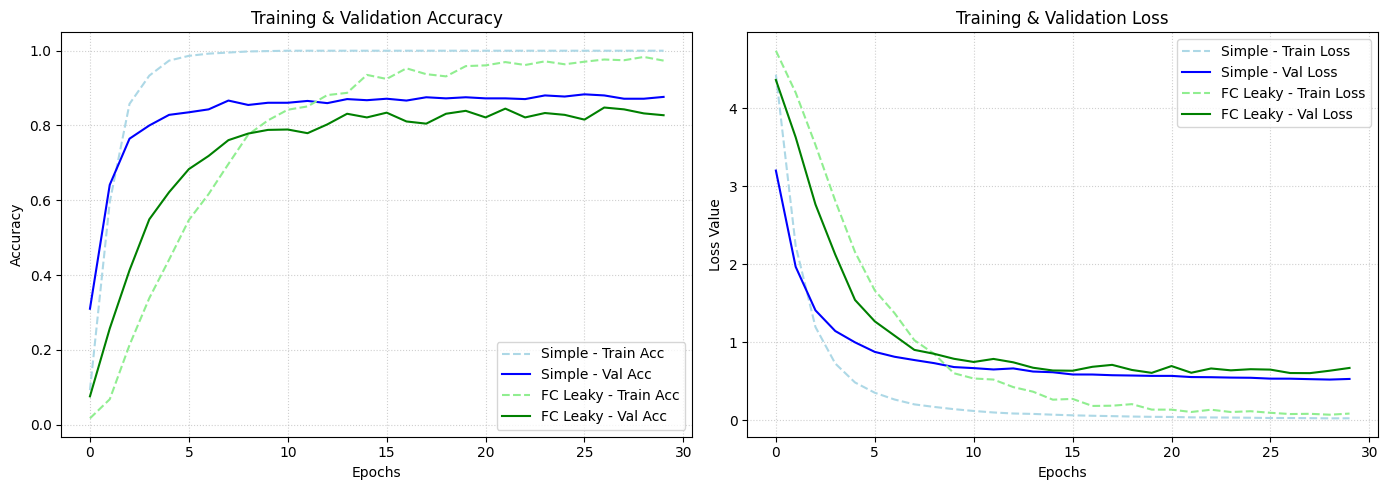

In [ ]:
import matplotlib.pyplot as plt

# 1. Set up a clean canvas for two side-by-side plots
plt.figure(figsize=(14, 5))

# --- PLOT 1: Accuracy Comparison ---
plt.subplot(1, 2, 1)
# Plot training & validation for the Original Simple Model
plt.plot(resnet_history.history['accuracy'], label='Simple - Train Acc', color='lightblue', linestyle='--')
plt.plot(resnet_history.history['val_accuracy'], label='Simple - Val Acc', color='blue')

# Plot training & validation for your New FC Leaky-ReLU Model
plt.plot(resnet_history_FC.history['accuracy'], label='FC Leaky - Train Acc', color='lightgreen', linestyle='--')
plt.plot(resnet_history_FC.history['val_accuracy'], label='FC Leaky - Val Acc', color='green')

plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- PLOT 2: Loss Comparison ---
plt.subplot(1, 2, 2)
# Plot training & validation loss for the Original Simple Model
plt.plot(resnet_history.history['loss'], label='Simple - Train Loss', color='lightblue', linestyle='--')
plt.plot(resnet_history.history['val_loss'], label='Simple - Val Loss', color='blue')

# Plot training & validation loss for your New FC Leaky-ReLU Model
plt.plot(resnet_history_FC.history['loss'], label='FC Leaky - Train Loss', color='lightgreen', linestyle='--')
plt.plot(resnet_history_FC.history['val_loss'], label='FC Leaky - Val Loss', color='green')

plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Render the layout cleanly
plt.tight_layout()
plt.show()

In [ ]:
# --- MODEL 3: ResNet_50 & DNN : Droupouts  ---

resnet50_base.trainable = False
model_DNN_DO = tf.keras.Sequential()
model_DNN_DO.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model_DNN_DO.add(resnet50_base)
model_DNN_DO.add(tf.keras.layers.GlobalAveragePooling2D())

model_DNN_DO.add(tf.keras.layers.Dense(1024))
model_DNN_DO.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO.add(tf.keras.layers.Dropout(0.3))

model_DNN_DO.add(tf.keras.layers.Dense(512))
model_DNN_DO.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO.add(tf.keras.layers.Dropout(0.3))

model_DNN_DO.add(tf.keras.layers.Dense(256))
model_DNN_DO.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO.add(tf.keras.layers.Dropout(0.3))

model_DNN_DO.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

model_DNN_DO.compile(
    optimizer= 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_DNN_DO.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,344,586 (100.50 MB)

 Trainable params: 2,756,874 (10.52 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
print("--- Training MODEL 3: ResNet_50 & DNN : Droupouts  ---")
t0 = time.time()
resnet_DNN_DO = model_DNN_DO.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_taken = time.time() - t0
best_accuracy = max(resnet_DNN_DO.history['val_accuracy']) * 100
print(f"\nBest Val Accuracy: {best_accuracy:.2f}%")
print(f"Training Time:     {time_taken/60:.1f} min")

In [ ]:
# --- MODEL 4: ResNet & DNN : Batch Normalization + Dropout ---

resnet50_base.trainable = False
model_DNN_DO_BN = tf.keras.Sequential()
model_DNN_DO_BN.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model_DNN_DO_BN.add(resnet50_base)
model_DNN_DO_BN.add(tf.keras.layers.GlobalAveragePooling2D())

model_DNN_DO_BN.add(tf.keras.layers.Dense(1024, use_bias=False))
model_DNN_DO_BN.add(tf.keras.layers.BatchNormalization())
model_DNN_DO_BN.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO_BN.add(tf.keras.layers.Dropout(0.4))

model_DNN_DO_BN.add(tf.keras.layers.Dense(512, use_bias=False))
model_DNN_DO_BN.add(tf.keras.layers.BatchNormalization())
model_DNN_DO_BN.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO_BN.add(tf.keras.layers.Dropout(0.4))

model_DNN_DO_BN.add(tf.keras.layers.Dense(256, use_bias=False))
model_DNN_DO_BN.add(tf.keras.layers.BatchNormalization())
model_DNN_DO_BN.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO_BN.add(tf.keras.layers.Dropout(0.4))

model_DNN_DO_BN.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

model_DNN_DO_BN.compile(
    optimizer= 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_DNN_DO_BN.summary()

# img_input_3 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# spatial_features_3 = resnet50_model(img_input_3, training=False)
# pooled_features_3 = tf.keras.layers.GlobalAveragePooling2D()(spatial_features_3)

# # --- Dense Block 01 (1024 Nodes) ---
# dense_layer_3_01 = tf.keras.layers.Dense(1024, use_bias=False)(pooled_features_3)
# dense_layer_3_01 = tf.keras.layers.BatchNormalization()(dense_layer_3_01)
# dense_layer_3_01 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_3_01)
# dense_layer_3_01 = tf.keras.layers.Dropout(0.4)(dense_layer_3_01)

# # --- Dense Block 02 (512 Nodes) ---
# dense_layer_3_02 = tf.keras.layers.Dense(512, use_bias=False)(dense_layer_3_01)
# dense_layer_3_02 = tf.keras.layers.BatchNormalization()(dense_layer_3_02)
# dense_layer_3_02 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_3_02)
# dense_layer_3_02 = tf.keras.layers.Dropout(0.4)(dense_layer_3_02)

# # --- Dense Block 03 (256 Nodes) ---
# dense_layer_3_03 = tf.keras.layers.Dense(256, use_bias=False)(dense_layer_3_02)
# dense_layer_3_03 = tf.keras.layers.BatchNormalization()(dense_layer_3_03)
# dense_layer_3_03 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_3_03)
# dense_layer_3_03 = tf.keras.layers.Dropout(0.4)(dense_layer_3_03)

# # --- Final Output Layer ---
# class_probabilities_3 = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(dense_layer_3_03)

# # --- Model Assembly & Compilation ---
# flower_model_v3 = tf.keras.Model(inputs=img_input_3, outputs=class_probabilities_3, name="Robust_BatchNorm_Head")
# flower_model_v3.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-3),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1024)           │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,349,962 (100.52 MB)

 Trainable params: 2,758,666 (10.52 MB)

 Non-trainable params: 23,591,296 (89.99 MB)

In [ ]:
print("--- Training MODEL 4: ResNet & DNN : Batch Normalization + Dropout ---")
t0 = time.time()
resnet_DNN_DO_BN = model_DNN_DO_BN.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_taken = time.time() - t0
best_accuracy = max(resnet_DNN_DO_BN.history['val_accuracy']) * 100
print(f"\nBest Val Accuracy: {best_accuracy:.2f}%")
print(f"Training Time:     {time_taken/60:.1f} min")

--- Training Model v3 (BatchNorm + High Dropout) ---
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.0559 - loss: 4.6850 - val_accuracy: 0.1598 - val_loss: 3.8577
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 490ms/step - accuracy: 0.2284 - loss: 3.4717 - val_accuracy: 0.3186 - val_loss: 3.0686
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 416ms/step - accuracy: 0.4157 - loss: 2.7377 - val_accuracy: 0.4951 - val_loss: 2.4350
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 419ms/step - accuracy: 0.5539 - loss: 2.2152 - val_accuracy: 0.5961 - val_loss: 2.0440
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 441ms/step - accuracy: 0.6902 - loss: 1.8171 - val_accuracy: 0.6706 - val_loss: 1.7789
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 473ms/step - accuracy: 0.7569 - loss: 1.4684 - val_accuracy: 0.7461 - val_loss: 1.5297
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 0.7931 - loss: 1.2664 - val_accuracy: 0.7696 - val_loss: 1.3563
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 413ms

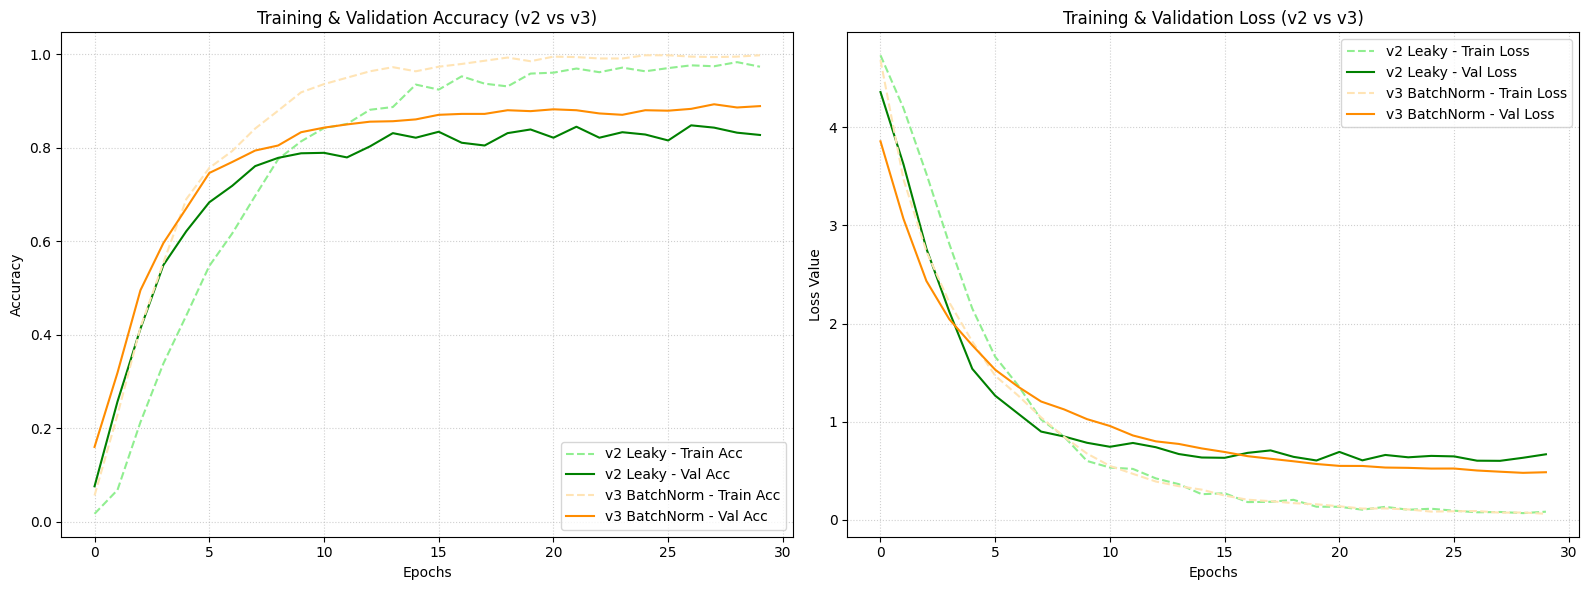

In [ ]:
import matplotlib.pyplot as plt

# 1. Set up a clean canvas for two side-by-side plots
plt.figure(figsize=(16, 6))

# --- PLOT 1: Accuracy Comparison (v2 vs v3) ---
plt.subplot(1, 2, 1)
# Model 2: FC Leaky Head / v2 (Green)
plt.plot(resnet_history_FC.history['accuracy'], label='v2 Leaky - Train Acc', color='lightgreen', linestyle='--')
plt.plot(resnet_history_FC.history['val_accuracy'], label='v2 Leaky - Val Acc', color='green')

# Model 3: BatchNorm + Higher Dropout / v3 (Orange)
plt.plot(resnet_history_v3.history['accuracy'], label='v3 BatchNorm - Train Acc', color='moccasin', linestyle='--')
plt.plot(resnet_history_v3.history['val_accuracy'], label='v3 BatchNorm - Val Acc', color='darkorange')

plt.title('Training & Validation Accuracy (v2 vs v3)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)


# --- PLOT 2: Loss Comparison (v2 vs v3) ---
plt.subplot(1, 2, 2)
# Model 2: FC Leaky Head / v2 (Green)
plt.plot(resnet_history_FC.history['loss'], label='v2 Leaky - Train Loss', color='lightgreen', linestyle='--')
plt.plot(resnet_history_FC.history['val_loss'], label='v2 Leaky - Val Loss', color='green')

# Model 3: BatchNorm + Higher Dropout / v3 (Orange)
plt.plot(resnet_history_v3.history['loss'], label='v3 BatchNorm - Train Loss', color='moccasin', linestyle='--')
plt.plot(resnet_history_v3.history['val_loss'], label='v3 BatchNorm - Val Loss', color='darkorange')

plt.title('Training & Validation Loss (v2 vs v3)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Render the layout cleanly
plt.tight_layout()
plt.show()

In [ ]:

# --- MODEL 5: ResNet & DNN : Batch Normalization + Dropout + Regularisation ---

resnet50_base.trainable = False
model_DNN_DO_BN_L2 = tf.keras.Sequential()
model_DNN_DO_BN_L2.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

model_DNN_DO_BN_L2.add(resnet50_base)
model_DNN_DO_BN_L2.add(tf.keras.layers.GlobalAveragePooling2D())

model_DNN_DO_BN_L2.add(tf.keras.layers.Dense(1024, use_bias=False, kernel_regularizer=l2(1e-4)))
model_DNN_DO_BN_L2.add(tf.keras.layers.BatchNormalization())
model_DNN_DO_BN_L2.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO_BN_L2.add(tf.keras.layers.Dropout(0.4))

model_DNN_DO_BN_L2.add(tf.keras.layers.Dense(512, use_bias=False, kernel_regularizer=l2(1e-4)))
model_DNN_DO_BN_L2.add(tf.keras.layers.BatchNormalization())
model_DNN_DO_BN_L2.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO_BN_L2.add(tf.keras.layers.Dropout(0.4))

model_DNN_DO_BN_L2.add(tf.keras.layers.Dense(256, use_bias=False, kernel_regularizer=l2( 1e-4)))
model_DNN_DO_BN_L2.add(tf.keras.layers.BatchNormalization())
model_DNN_DO_BN_L2.add(tf.keras.layers.LeakyReLU(negative_slope=0.01))
model_DNN_DO_BN_L2.add(tf.keras.layers.Dropout(0.4))

model_DNN_DO_BN_L2.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

model_DNN_DO_BN_L2.compile(
    optimizer= 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_DNN_DO_BN_L2.summary()

# img_input_4 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# spatial_features_4 = resnet50_model(img_input_4, training=False)
# pooled_features_4 = tf.keras.layers.GlobalAveragePooling2D()(spatial_features_4)

# # --- Dense Block 01 (1024 Nodes) ---
# dense_layer_3_01 = tf.keras.layers.Dense(1024, use_bias=False, kernel_regularizer=l2(1e-4))(pooled_features_4)
# dense_layer_3_01 = tf.keras.layers.BatchNormalization()(dense_layer_3_01)
# dense_layer_3_01 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_3_01)
# dense_layer_3_01 = tf.keras.layers.Dropout(0.4)(dense_layer_3_01)

# # --- Dense Block 02 (512 Nodes) ---
# dense_layer_3_02 = tf.keras.layers.Dense(512, use_bias=False,kernel_regularizer=l2(1e-4))(dense_layer_3_01)
# dense_layer_3_02 = tf.keras.layers.BatchNormalization()(dense_layer_3_02)
# dense_layer_3_02 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_3_02)
# dense_layer_3_02 = tf.keras.layers.Dropout(0.4)(dense_layer_3_02)

# # --- Dense Block 03 (256 Nodes) ---
# dense_layer_3_03 = tf.keras.layers.Dense(256, use_bias=False, kernel_regularizer=l2(1e-4))(dense_layer_3_02)
# dense_layer_3_03 = tf.keras.layers.BatchNormalization()(dense_layer_3_03)
# dense_layer_3_03 = tf.keras.layers.LeakyReLU(negative_slope=0.01)(dense_layer_3_03)
# dense_layer_3_03 = tf.keras.layers.Dropout(0.4)(dense_layer_3_03)

# # --- Final Output Layer ---
# class_probabilities_3 = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(dense_layer_3_03)

# # --- Model Assembly & Compilation ---
# flower_model_v4 = tf.keras.Model(inputs=img_input_4, outputs=class_probabilities_3, name="Robust_BatchNorm_Head")
# flower_model_v4.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-3),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )
# flower_model_v4.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1024)           │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,349,962 (100.52 MB)

 Trainable params: 2,758,666 (10.52 MB)

 Non-trainable params: 23,591,296 (89.99 MB)

In [ ]:
# print("--- Training Model v4 (Batch Normalization + Dropout + Regularisation) ---")
# t0 = time.time()

# # Save history separately to protect previous model logs
# resnet_history_v4 = flower_model_v4.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# resnet_time_v4 = time.time() - t0
# resnet_best_v4 = max(resnet_history_v4.history['val_accuracy']) * 100
# print(f"\nBest Val Accuracy: {resnet_best_v4:.2f}%")


print("--- Training MODEL 5: ResNet & DNN : Batch Normalization + Dropout + Regularisation ---")
t0 = time.time()
resnet_DNN_DO_BN_L2 = model_DNN_DO_BN_L2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_taken = time.time() - t0
best_accuracy = max(resnet_DNN_DO_BN_L2.history['val_accuracy']) * 100
print(f"\nBest Val Accuracy: {best_accuracy:.2f}%")
print(f"Training Time:     {time_taken/60:.1f} min")



--- Training Model v4 (Batch Normalization + Dropout + Regularisation) ---
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.0402 - loss: 4.9494 - val_accuracy: 0.2039 - val_loss: 4.0650
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 534ms/step - accuracy: 0.2402 - loss: 3.6712 - val_accuracy: 0.3373 - val_loss: 3.2652
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 460ms/step - accuracy: 0.4196 - loss: 2.9779 - val_accuracy: 0.4765 - val_loss: 2.6946
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 416ms/step - accuracy: 0.5676 - loss: 2.4564 - val_accuracy: 0.6078 - val_loss: 2.2793
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - accuracy: 0.6647 - loss: 2.0454 - val_accuracy: 0.6833 - val_loss: 1.9754
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 413ms/step - accuracy: 0.7235 - loss: 1.7589 - val_accuracy: 0.7500 - val_loss: 1.7783
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 481ms/step - accuracy: 0.8284 - loss: 1.4161 - val_accuracy: 0.7833 - val_loss: 1.6226
Epoch 8/30
16/16 ━━━━━━━━━

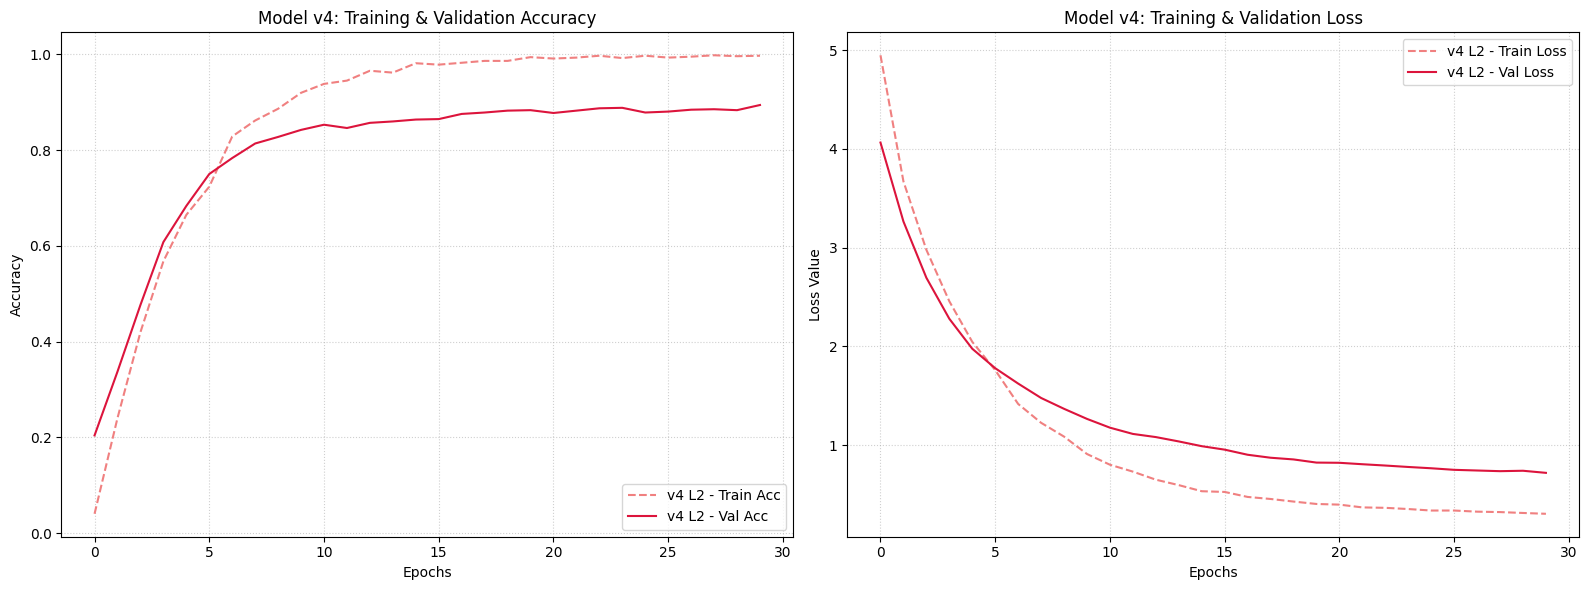

In [ ]:
import matplotlib.pyplot as plt

# 1. Set up a clean canvas for two side-by-side plots
plt.figure(figsize=(16, 6))

# --- PLOT 1: Accuracy (Model v4 Only) ---
plt.subplot(1, 2, 1)
plt.plot(resnet_history_v4.history['accuracy'], label='v4 L2 - Train Acc', color='lightcoral', linestyle='--')
plt.plot(resnet_history_v4.history['val_accuracy'], label='v4 L2 - Val Acc', color='crimson')

plt.title('Model v4: Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- PLOT 2: Loss (Model v4 Only) ---
plt.subplot(1, 2, 2)
plt.plot(resnet_history_v4.history['loss'], label='v4 L2 - Train Loss', color='lightcoral', linestyle='--')
plt.plot(resnet_history_v4.history['val_loss'], label='v4 L2 - Val Loss', color='crimson')

plt.title('Model v4: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Render the layout cleanly
plt.tight_layout()
plt.show()

In [ ]:

# --- MODEL 6: Fine Tunning ResNet & DNN : Batch Normalization + Dropout + Regularisation ---

resnet50_finetune_base = tf.keras.applications.ResNet50(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False
)

resnet50_finetune_base.trainable = True
total_layers = len(resnet50_finetune_base.layers)

# Refreezing all the layers upto layer 140
for (counter,layer) in enumerate(resnet50_finetune_base.layers[:140]):
    layer.trainable = False
    counter += 1

print(f"Total layers in ResNet-50: {total_layers}")
print(f"Number of trainable layers: {total_layers - counter}")

Total layers in ResNet-50: 175
Number of trainable layers: 35


New Base ID target:                     139641974679616


ValueError: Input 0 with name 'None' of layer 'batch_normalization_12' is incompatible with the layer: expected axis -1 of input shape to have value 1024, but received input with shape (None, 2048)

In [ ]:
# flower_model_v3.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Tiny learning rate!
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

In [ ]:
FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

t0 = time.time()

# Notice 'initial_epoch=30' - this keeps history lines continuous!
fine_tune_history = flower_model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=EPOCHS
)

best_val_acc = max(fine_tune_history.history['val_accuracy']) * 100
print(f"\nFine-Tuning Complete in {(time.time()-t0)/60:.1f} minutes!")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 31/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9431 - loss: 0.3030 - val_accuracy: 0.8794 - val_loss: 0.4840
Epoch 32/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 567ms/step - accuracy: 0.9598 - loss: 0.2588 - val_accuracy: 0.8775 - val_loss: 0.4849
Epoch 33/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 531ms/step - accuracy: 0.9676 - loss: 0.2109 - val_accuracy: 0.8863 - val_loss: 0.4724
Epoch 34/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 481ms/step - accuracy: 0.9784 - loss: 0.1918 - val_accuracy: 0.8775 - val_loss: 0.4955
Epoch 35/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 616ms/step - accuracy: 0.9775 - loss: 0.1675 - val_accuracy: 0.8833 - val_loss: 0.5000
Epoch 36/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 501ms/step - accuracy: 0.9765 - loss: 0.1850 - val_accuracy: 0.8637 - val_loss: 0.5038
Epoch 37/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step - accuracy: 0.9804 - loss: 0.1501 - val_accuracy: 0.8706 - val_loss: 0.5072
Epoch 38/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step - accuracy: 0.9873 - loss: 0.1333 - val

In [ ]:
for layer in resnet50_model.layers:
    if layer.trainable and hasattr(layer, 'kernel_regularizer'):
        layer.kernel_regularizer = l2(1e-4)

flower_model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Microscopic steps
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

t0 = time.time()

# Notice 'initial_epoch=30' - this keeps history lines continuous!
fine_tune_history_2 = flower_model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=EPOCHS
)

best_val_acc = max(fine_tune_history.history['val_accuracy']) * 100
print(f"\nFine-Tuning Complete in {(time.time()-t0)/60:.1f} minutes!")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 31/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9902 - loss: 0.1027 - val_accuracy: 0.8696 - val_loss: 0.5121
Epoch 32/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 503ms/step - accuracy: 0.9892 - loss: 0.0854 - val_accuracy: 0.8843 - val_loss: 0.4993
Epoch 33/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 536ms/step - accuracy: 0.9951 - loss: 0.0860 - val_accuracy: 0.8863 - val_loss: 0.4911
Epoch 34/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 552ms/step - accuracy: 0.9931 - loss: 0.0925 - val_accuracy: 0.8725 - val_loss: 0.5137
Epoch 35/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 509ms/step - accuracy: 0.9931 - loss: 0.0766 - val_accuracy: 0.8794 - val_loss: 0.4984
Epoch 36/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 497ms/step - accuracy: 0.9912 - loss: 0.0807 - val_accuracy: 0.8824 - val_loss: 0.4731
Epoch 37/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 616ms/step - accuracy: 0.9961 - loss: 0.0778 - val_accuracy: 0.8775 - val_loss: 0.4962
Epoch 38/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 488ms/step - accuracy: 0.9980 - loss: 0.0755 - val

In [ ]:
# FINE_TUNE_EPOCHS = 15
# TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

# t0 = time.time()

# # Notice 'initial_epoch=30' - this keeps history lines continuous!
# fine_tune_history_2 = flower_model_v3.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=TOTAL_EPOCHS,
#     initial_epoch=EPOCHS
# )

# best_val_acc = max(fine_tune_history.history['val_accuracy']) * 100
# print(f"\nFine-Tuning Complete in {(time.time()-t0)/60:.1f} minutes!")
# print(f"Best Val Accuracy: {best_val_acc:.2f}%")